In [42]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report

# other
from meteocalc import dew_point

In [4]:
DATA_DIR = Path("../data/kaggle-irrigation")
SEED = 42

# Feature Engineering Pipeline

In [15]:
def add_features(d: pd.DataFrame):
    d = d.copy()

    d["heat_stress"]   = (d["Temperature_C"] * d["Sunlight_Hours"]).astype(int)
    d["drying_force"]  = (d["Wind_Speed_kmh"] * d["Temperature_C"] / (d["Humidity"] + 1)).astype(int)
    d["soil_quality"]  = (d["Organic_Carbon"] / (d["Electrical_Conductivity"] + 0.1)).astype(int)
    d["dew_point"] = d.apply(lambda row: dew_point(row["Temperature_C"], row["Humidity"]).c, axis=1)

    return d

feature_pipe = FunctionTransformer(add_features)

# Get Training Data

In [10]:
df = pd.read_csv(DATA_DIR / "train.csv", index_col="id")
df

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High


In [16]:
X = df.drop(columns=["Irrigation_Need"])
y = df["Irrigation_Need"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, shuffle=True, stratify=y, random_state=SEED)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Benchmarking With Default Rule

In [24]:
model = GaussianNB()
bench = Pipeline(
    [
        ("feature_adder", feature_pipe),
        ("dummify", ColumnTransformer(transformers=[
            ("dummify", OneHotEncoder(sparse_output=False), make_column_selector(dtype_include="object"))
        ])),
        ("model", model)
    ]
)

bench.fit(X_train, y_train)

bench_preds_proba = bench.predict_proba(X_test)
bench_preds = bench_preds_proba.argmax(axis=1)

balanced_accuracy_score(y_test, bench_preds)

0.6219655956226048

# Single-Class Focus

In [31]:
# focus on class 0 -> minority class
classes = bench.classes_
print("Classes:", classes)
print("Train counts:", np.unique(y_train, return_counts=True))

Classes: [0 1 2]
Train counts: (array([0, 1, 2]), array([ 16807, 295934, 191259], dtype=int64))


In [ ]:
focus_class = classes[0]
focus_idx = list(classes).index(focus_class)

In [32]:
def evaluate_thresholds(y_true, probs, focus_class, classes, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)

    focus_idx = list(classes).index(focus_class)
    focus_proba = probs[:, focus_idx]

    # Binarize y_true: 1 if it's the focus class, 0 otherwise
    y_binary = (y_true == focus_class).astype(int)

    rows = []
    for t in thresholds:
        preds = (focus_proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_binary, preds, zero_division=0),
            "recall": recall_score(y_binary, preds, zero_division=0),
            "f1": f1_score(y_binary, preds, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_binary, preds)
        })
    return pd.DataFrame(rows)

In [40]:
results = evaluate_thresholds(
    y_true=y_test,
    probs=bench_preds_proba,
    focus_class=bench.classes_[0],
    classes=bench.classes_
)

print(results)

    threshold  precision    recall        f1  balanced_accuracy
0        0.10   0.108240  0.846264  0.191931           0.802863
1        0.15   0.109313  0.839362  0.193435           0.801707
2        0.20   0.110913  0.828415  0.195633           0.799657
3        0.25   0.113324  0.806997  0.198740           0.794580
4        0.30   0.115435  0.783674  0.201228           0.788248
5        0.35   0.117725  0.757734  0.203789           0.780910
6        0.40   0.121641  0.719657  0.208107           0.770188
7        0.45   0.123562  0.674679  0.208871           0.754789
8        0.50   0.126952  0.630652  0.211357           0.740514
9        0.55   0.130670  0.569015  0.212533           0.719207
10       0.60   0.135522  0.508805  0.214035           0.698417
11       0.65   0.140371  0.447168  0.213668           0.676346
12       0.70   0.147129  0.368872  0.210355           0.647551
13       0.75   0.155609  0.277963  0.199522           0.612963
14       0.80   0.164772  0.182770  0.17

In [41]:
# Find the best threshold for your chosen metric
best_row = results.loc[results["f1"].idxmax()]
print("\nBest threshold by F1:", best_row["threshold"])
print("\nBest threshold by Precision:", results.loc[results["precision"].idxmax()])
print("\nBest threshold by Recall:", results.loc[results["recall"].idxmax()])
print("\nBest threshold by Balanced Accuracy:", results.loc[results["balanced_accuracy"].idxmax()])
print(best_row)


Best threshold by F1: 0.6

Best threshold by Precision: threshold            0.900000
precision            0.177358
recall               0.011185
f1                   0.021043
balanced_accuracy    0.504698
Name: 16, dtype: float64

Best threshold by Recall: threshold            0.100000
precision            0.108240
recall               0.846264
f1                   0.191931
balanced_accuracy    0.802863
Name: 0, dtype: float64

Best threshold by Balanced Accuracy: threshold            0.100000
precision            0.108240
recall               0.846264
f1                   0.191931
balanced_accuracy    0.802863
Name: 0, dtype: float64
threshold            0.600000
precision            0.135522
recall               0.508805
f1                   0.214035
balanced_accuracy    0.698417
Name: 10, dtype: float64


In [43]:
from sklearn.metrics import classification_report

# Pick your best threshold from the sweep
best_threshold = 0.60   # or whatever you decide on
focus_class = bench.classes_[0]   # Class 0
classes = bench.classes_

# Build thresholded predictions (3-class output, not binary)
focus_idx = list(classes).index(focus_class)
focus_proba = bench_preds_proba[:, focus_idx]

other_idx = [i for i in range(len(classes)) if i != focus_idx]
fallback = np.array([classes[other_idx[i]] for i in
                     bench_preds_proba[:, other_idx].argmax(axis=1)])

thresh_preds = np.where(focus_proba >= best_threshold, focus_class, fallback)

# Default rule
print("=== Default (argmax) predictions ===")
print(classification_report(y_test, bench_preds, digits=3))

# Thresholded rule
print(f"=== Thresholded predictions (t={best_threshold} on Class {focus_class}) ===")
print(classification_report(y_test, thresh_preds, digits=3))

=== Default (argmax) predictions ===
              precision    recall  f1-score   support

           0      0.126     0.633     0.211      4202
           1      0.860     0.734     0.792     73983
           2      0.570     0.499     0.532     47815

    accuracy                          0.641    126000
   macro avg      0.519     0.622     0.512    126000
weighted avg      0.726     0.641     0.674    126000

=== Thresholded predictions (t=0.6 on Class 0) ===
              precision    recall  f1-score   support

           0      0.136     0.509     0.214      4202
           1      0.860     0.734     0.792     73983
           2      0.590     0.581     0.586     47815

    accuracy                          0.668    126000
   macro avg      0.529     0.608     0.531    126000
weighted avg      0.734     0.668     0.694    126000



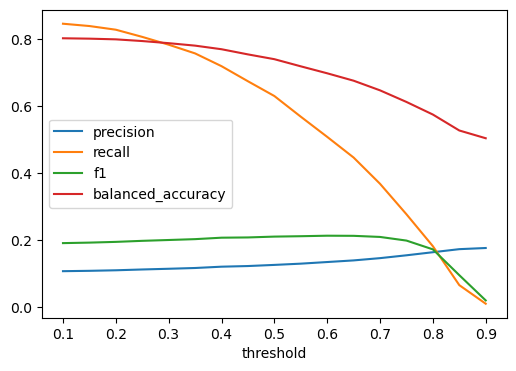

In [38]:
import matplotlib.pyplot as plt

results = results.sort_values("threshold")

fig, ax = plt.subplots(figsize=(6, 4))

results.plot(kind="line", x="threshold", y="precision", ax=ax)
results.plot(kind="line", x="threshold", y="recall", ax=ax)
results.plot(kind="line", x="threshold", y="f1", ax=ax)
results.plot(kind="line", x="threshold", y="balanced_accuracy", ax=ax)

plt.show()

# Discussion

- I chose to focus on the minority class: _Class 0_, which has 16,807 observations in the training data.

- We tune the threshold using a One-Versus-Rest technique; "is the given example _Class 0_ or _Not Class 0_?"

- `balanced_accuracy`, `recall`, and `f1`, decrease as the threshold increases. This is likely because we are telling the model it needs to be more confident in its prediction for us to accept it. Given that we are focusing on the minority class, the model, in most scenarios, will be less confident of its _Class 0_ predictions.

- This is further supported by an increasing `precision`, where the model becomes more accurate as we increase the required confidence it needs before we accept a prediction.

- The tradeoff here is that we get better at predicting _Not Class 0_, but much worse at predicting _Class 0_. Looking at the `classification_reports`, we see that the most notable improvement of the threshold-tuned model was in _Class 2's_ metrics. This supports the idea that the model got better at _Not Class 0_ and tells us that the model was getting Class 0 and Class 2 confused.

- Compared to our other models, Gaussian Naive Bayes struggles. It assumes that features are conditionally independent and that continuous features are normally distributed within each class. Our data violates both of these assumptions.